# Single CW: Pulsar Distance Likelihood Landscape

**Question:** For a single continuous wave source with correctly identified global parameters
and noise, how much does the log-likelihood change when pulsar distances are correct vs wrong?

We inject a single CW at three signal strengths (`log10_h = -14.0, -13.5, -13.0`),
fix all global CW + noise parameters at truth, and scan each pulsar's distance to map
the oscillatory likelihood landscape. The key metric is the height difference between
the truth-distance peak and the best alternative (wrong-mode) peak.

**Expectation:** For a single CW, the likelihood is periodic in each pulsar's distance
with spacing $\Delta L = 1 / (f_{\rm gw} \cdot \kappa_{\rm kpc/c} \cdot |1 - \cos\mu|)$.
Alternative mode peaks should be nearly as high as the truth peak, because each mode
corresponds to a valid phase assignment for the pulsar term.


In [1]:
import sys, importlib
sys.path.insert(0, ".")
import cw_helpers
importlib.reload(cw_helpers)
from cw_helpers import *
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


/home/mattm/miniforge3/envs/discotech/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


## 1. Load pulsars

In [2]:
Npulsars = 10
ent_psrs, disco_psrs = load_pulsars(Npulsars)
print(f"Loaded {len(ent_psrs)} pulsars:")
for p in ent_psrs:
    print(f"  {p.name:16s}  pdist = {p.pdist[0]:.3f} +/- {p.pdist[1]:.3f} kpc   Ntoas = {len(p.toas)}")


FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

## 2. Build enterprise PTA (1 CW source) for simulation

In [3]:
num_cw = 1
pta, cw_block_names, Tspan = build_enterprise_pta(ent_psrs, num_cw)
print(f"PTA built: {len(pta.param_names)} parameters, Tspan = {Tspan/3.156e7:.1f} yr")


PTA built: 130 parameters, Tspan = 19.9 yr


## 3. Scan distance landscape at three signal strengths

For each `log10_h`, we:
1. Generate injection parameters and simulate data
2. Build the discovery likelihood (fixing all params at truth)
3. Scan each pulsar's distance over ~10 mode spacings
4. Find peaks and compare truth peak to best wrong-mode peak


In [4]:
log10_h_values = [-14.0, -13.5, -13.0]
seed = 1234

# Storage for all results
all_results = {}

for log10_h in log10_h_values:
    print(f"\n{'='*60}")
    print(f"log10_h = {log10_h}")
    print(f"{'='*60}")

    rng = np.random.default_rng(seed)
    np.random.seed(seed)

    # Generate injection
    inj_params = generate_injection_params(
        pta, ent_psrs, num_cw, cw_block_names, log10_h, scenario="single", rng=rng,
    )

    # Simulate
    sim_resids = simulate(pta, inj_params)
    resid_map = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}

    # Build likelihood
    logl_fn, param_keys, base_vals = build_disco_likelihood(
        disco_psrs, resid_map, num_cw, inj_params, cw_block_names,
    )

    # Warm up JIT
    _ = logl_fn(base_vals)
    print(f"  ln L(truth) = {float(logl_fn(base_vals)):.2f}")

    # Get CW params for mode spacing calculation
    cw_cos_gwtheta = inj_params["cw_cos_gwtheta"]
    cw_gwphi = inj_params["cw_gwphi"]
    cw_log10_fgw = inj_params["cw_log10_fgw"]

    results = {}
    for psr_e, psr_d in zip(ent_psrs, disco_psrs):
        pname = psr_e.name
        true_dist = psr_e.pdist[0]
        dist_key = f"{pname}_cw_p_dist"

        if dist_key not in param_keys:
            continue

        # Mode spacing
        dL = compute_mode_spacing(cw_cos_gwtheta, cw_gwphi, cw_log10_fgw, psr_d.pos)

        # Scan range: truth +/- 5 mode spacings, but stay positive
        n_modes_scan = 10
        scan_half = n_modes_scan * dL
        scan_min = max(0.01, true_dist - scan_half)
        scan_max = true_dist + scan_half

        print(f"  {pname}: dL = {dL:.4f} kpc, scanning [{scan_min:.3f}, {scan_max:.3f}]")

        scan_d, scan_ll = scan_pulsar_distance(
            logl_fn, base_vals, param_keys, dist_key,
            scan_min, scan_max, n_points=3000,
        )

        analysis = analyze_peaks(scan_d, scan_ll, true_dist, mode_spacing=dL)
        analysis["scan_d"] = scan_d
        analysis["scan_ll"] = scan_ll
        analysis["true_dist"] = true_dist
        analysis["dL"] = dL
        results[pname] = analysis

        delta = analysis["delta_lnL_truth_vs_best_wrong"]
        print(f"    -> {analysis['n_peaks']} peaks, "
              f"Delta ln L (truth - best wrong) = {delta:.2f}" if not np.isnan(delta) else
              f"    -> {analysis['n_peaks']} peaks, no wrong peaks found")

    all_results[log10_h] = results
    jax.clear_caches()

print("\nDone!")



log10_h = -14.0
  ln L(truth) = 37585.25
  B1855+09: dL = 0.0005 kpc, scanning [1.175, 1.185]
    -> 3 peaks, Delta ln L (truth - best wrong) = -0.00
  B1937+21: dL = 0.0006 kpc, scanning [3.094, 3.106]
    -> 3 peaks, Delta ln L (truth - best wrong) = -0.00
  B1953+29: dL = 0.0006 kpc, scanning [4.634, 4.646]
    -> 3 peaks, Delta ln L (truth - best wrong) = -0.00
  J0023+0923: dL = 0.0016 kpc, scanning [1.004, 1.036]
    -> 45 peaks, Delta ln L (truth - best wrong) = -0.00
  J0030+0451: dL = 0.0018 kpc, scanning [0.312, 0.348]
    -> 53 peaks, Delta ln L (truth - best wrong) = -0.00
  J0125-2327: dL = 0.0039 kpc, scanning [0.834, 0.912]
    -> 0 peaks, no wrong peaks found
  J0340+4130: dL = 0.0018 kpc, scanning [1.692, 1.728]
    -> 51 peaks, Delta ln L (truth - best wrong) = -0.00
  J0406+3039: dL = 0.0026 kpc, scanning [1.694, 1.746]
    -> 81 peaks, Delta ln L (truth - best wrong) = -0.00
  J0437-4715: dL = 0.0087 kpc, scanning [0.068, 0.242]
    -> 0 peaks, no wrong peaks found

## 4. Distance landscape plots

Each panel shows the log-likelihood as a function of one pulsar's distance (all other
params fixed at truth). The vertical red dashed line marks the injected distance.
Peaks are marked with dots. The truth peak is green; wrong-mode peaks are orange.


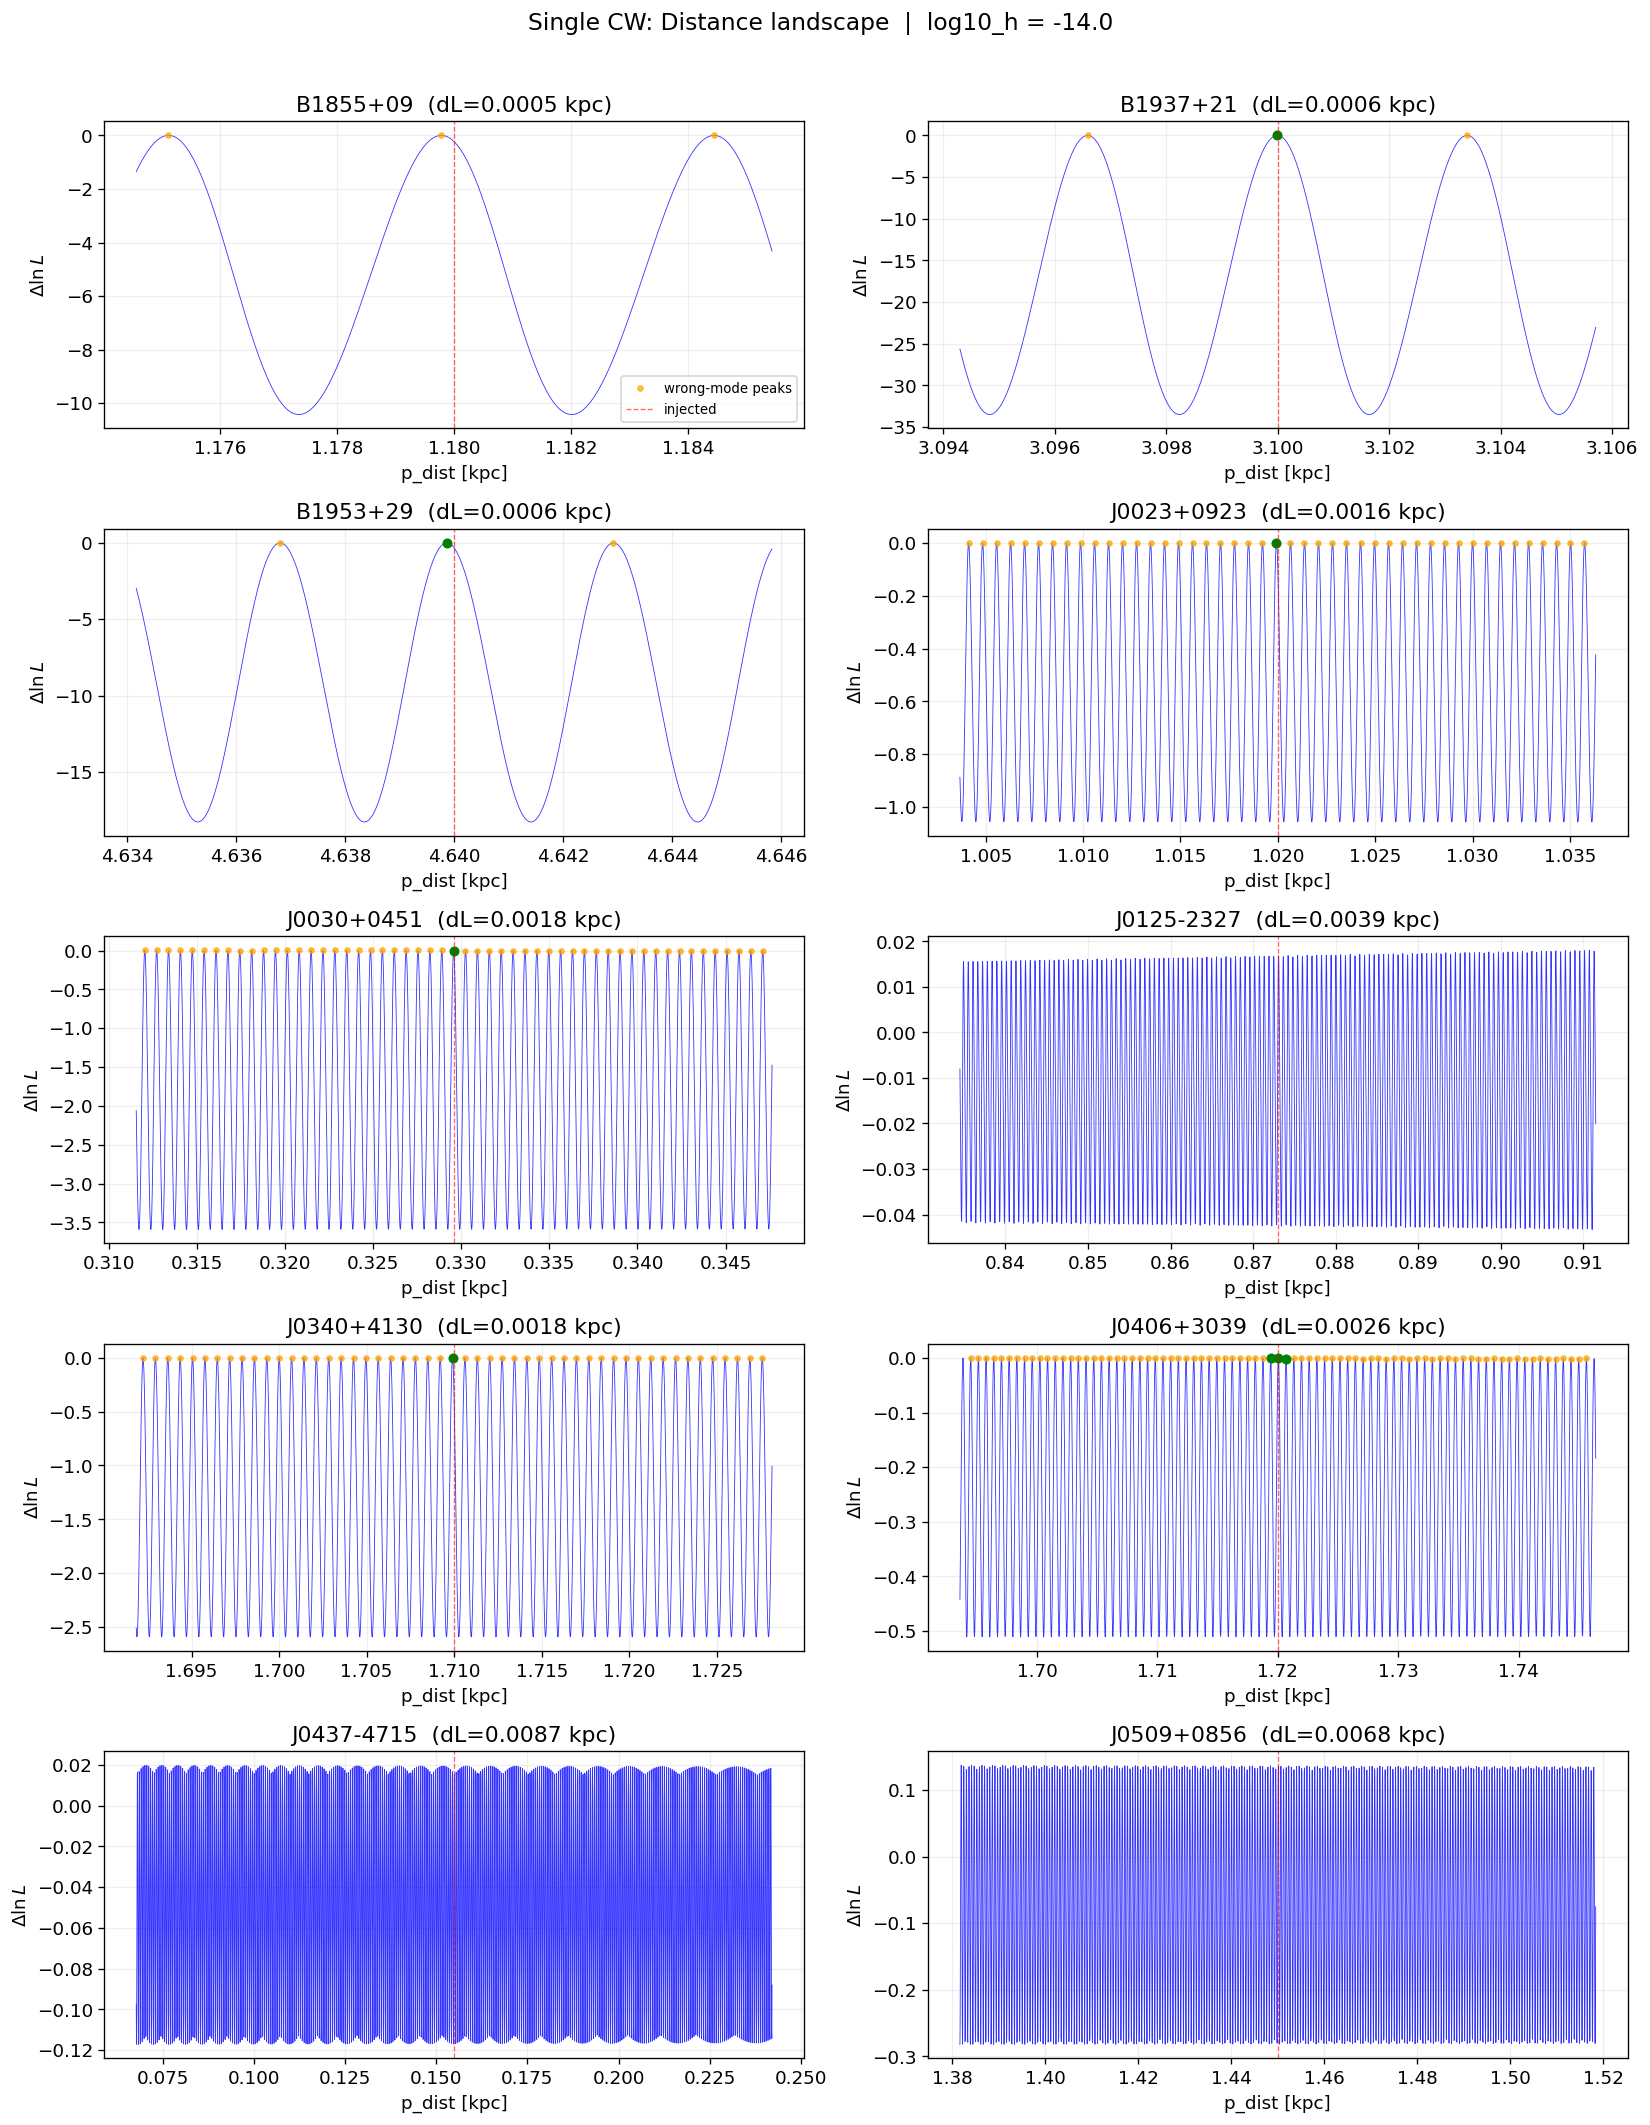

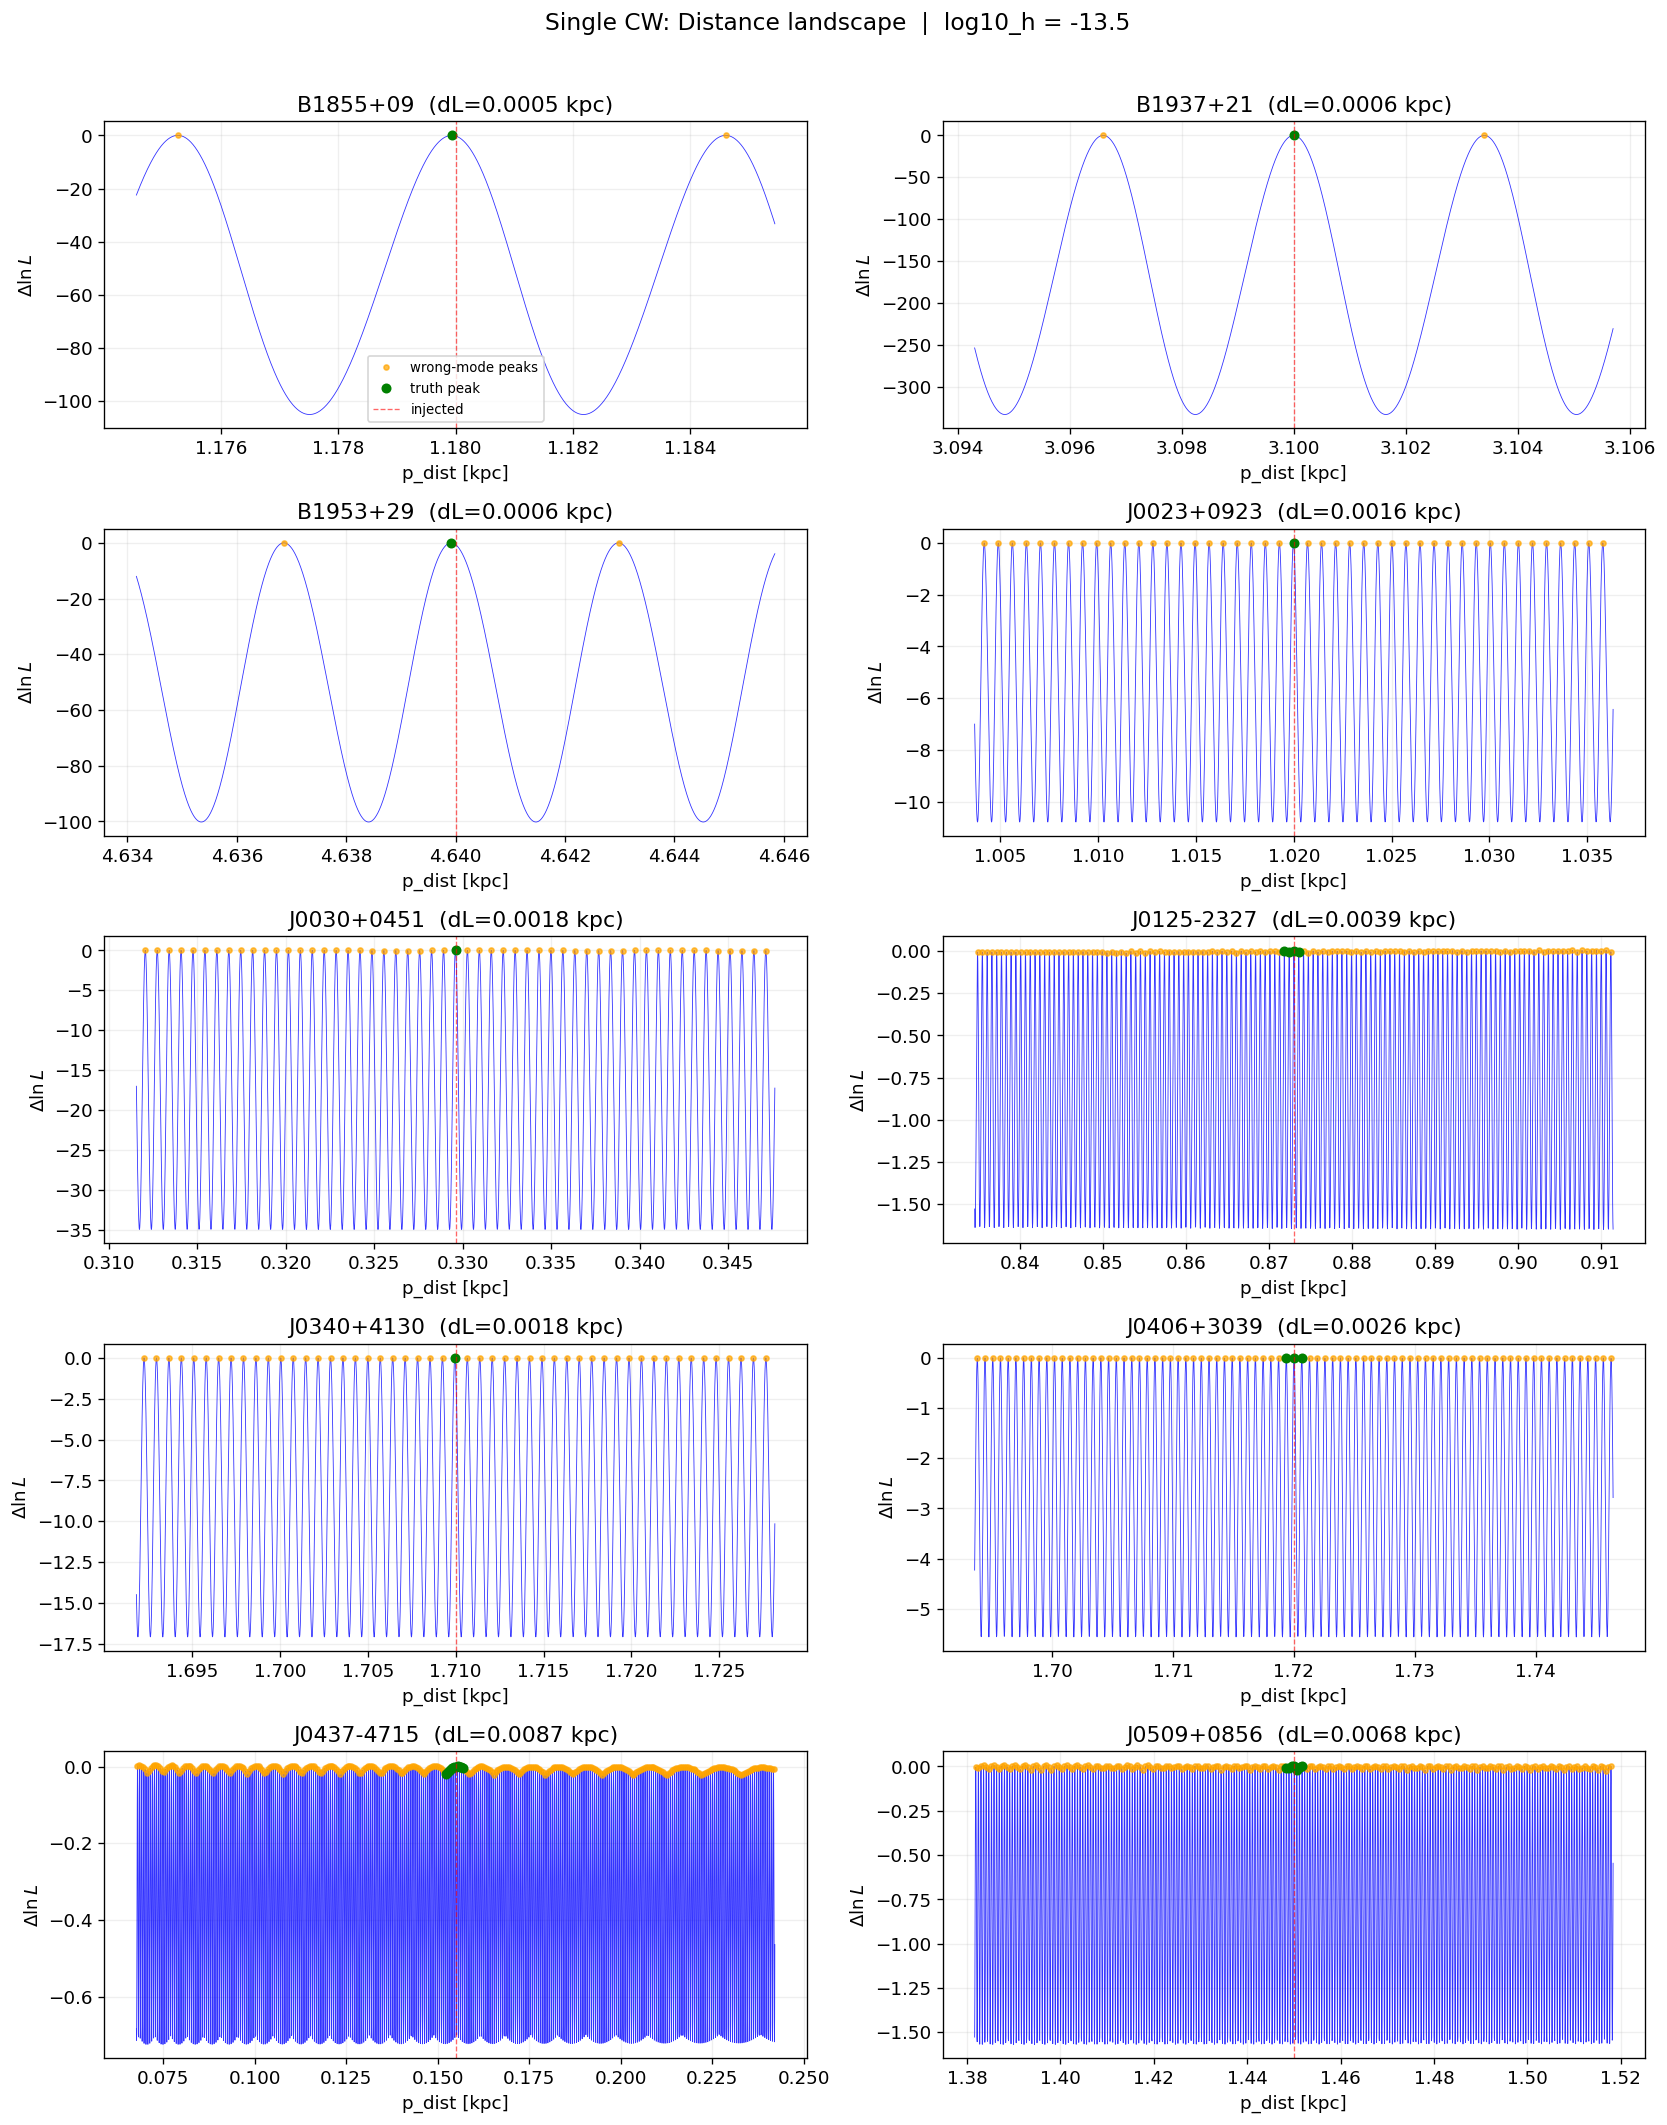

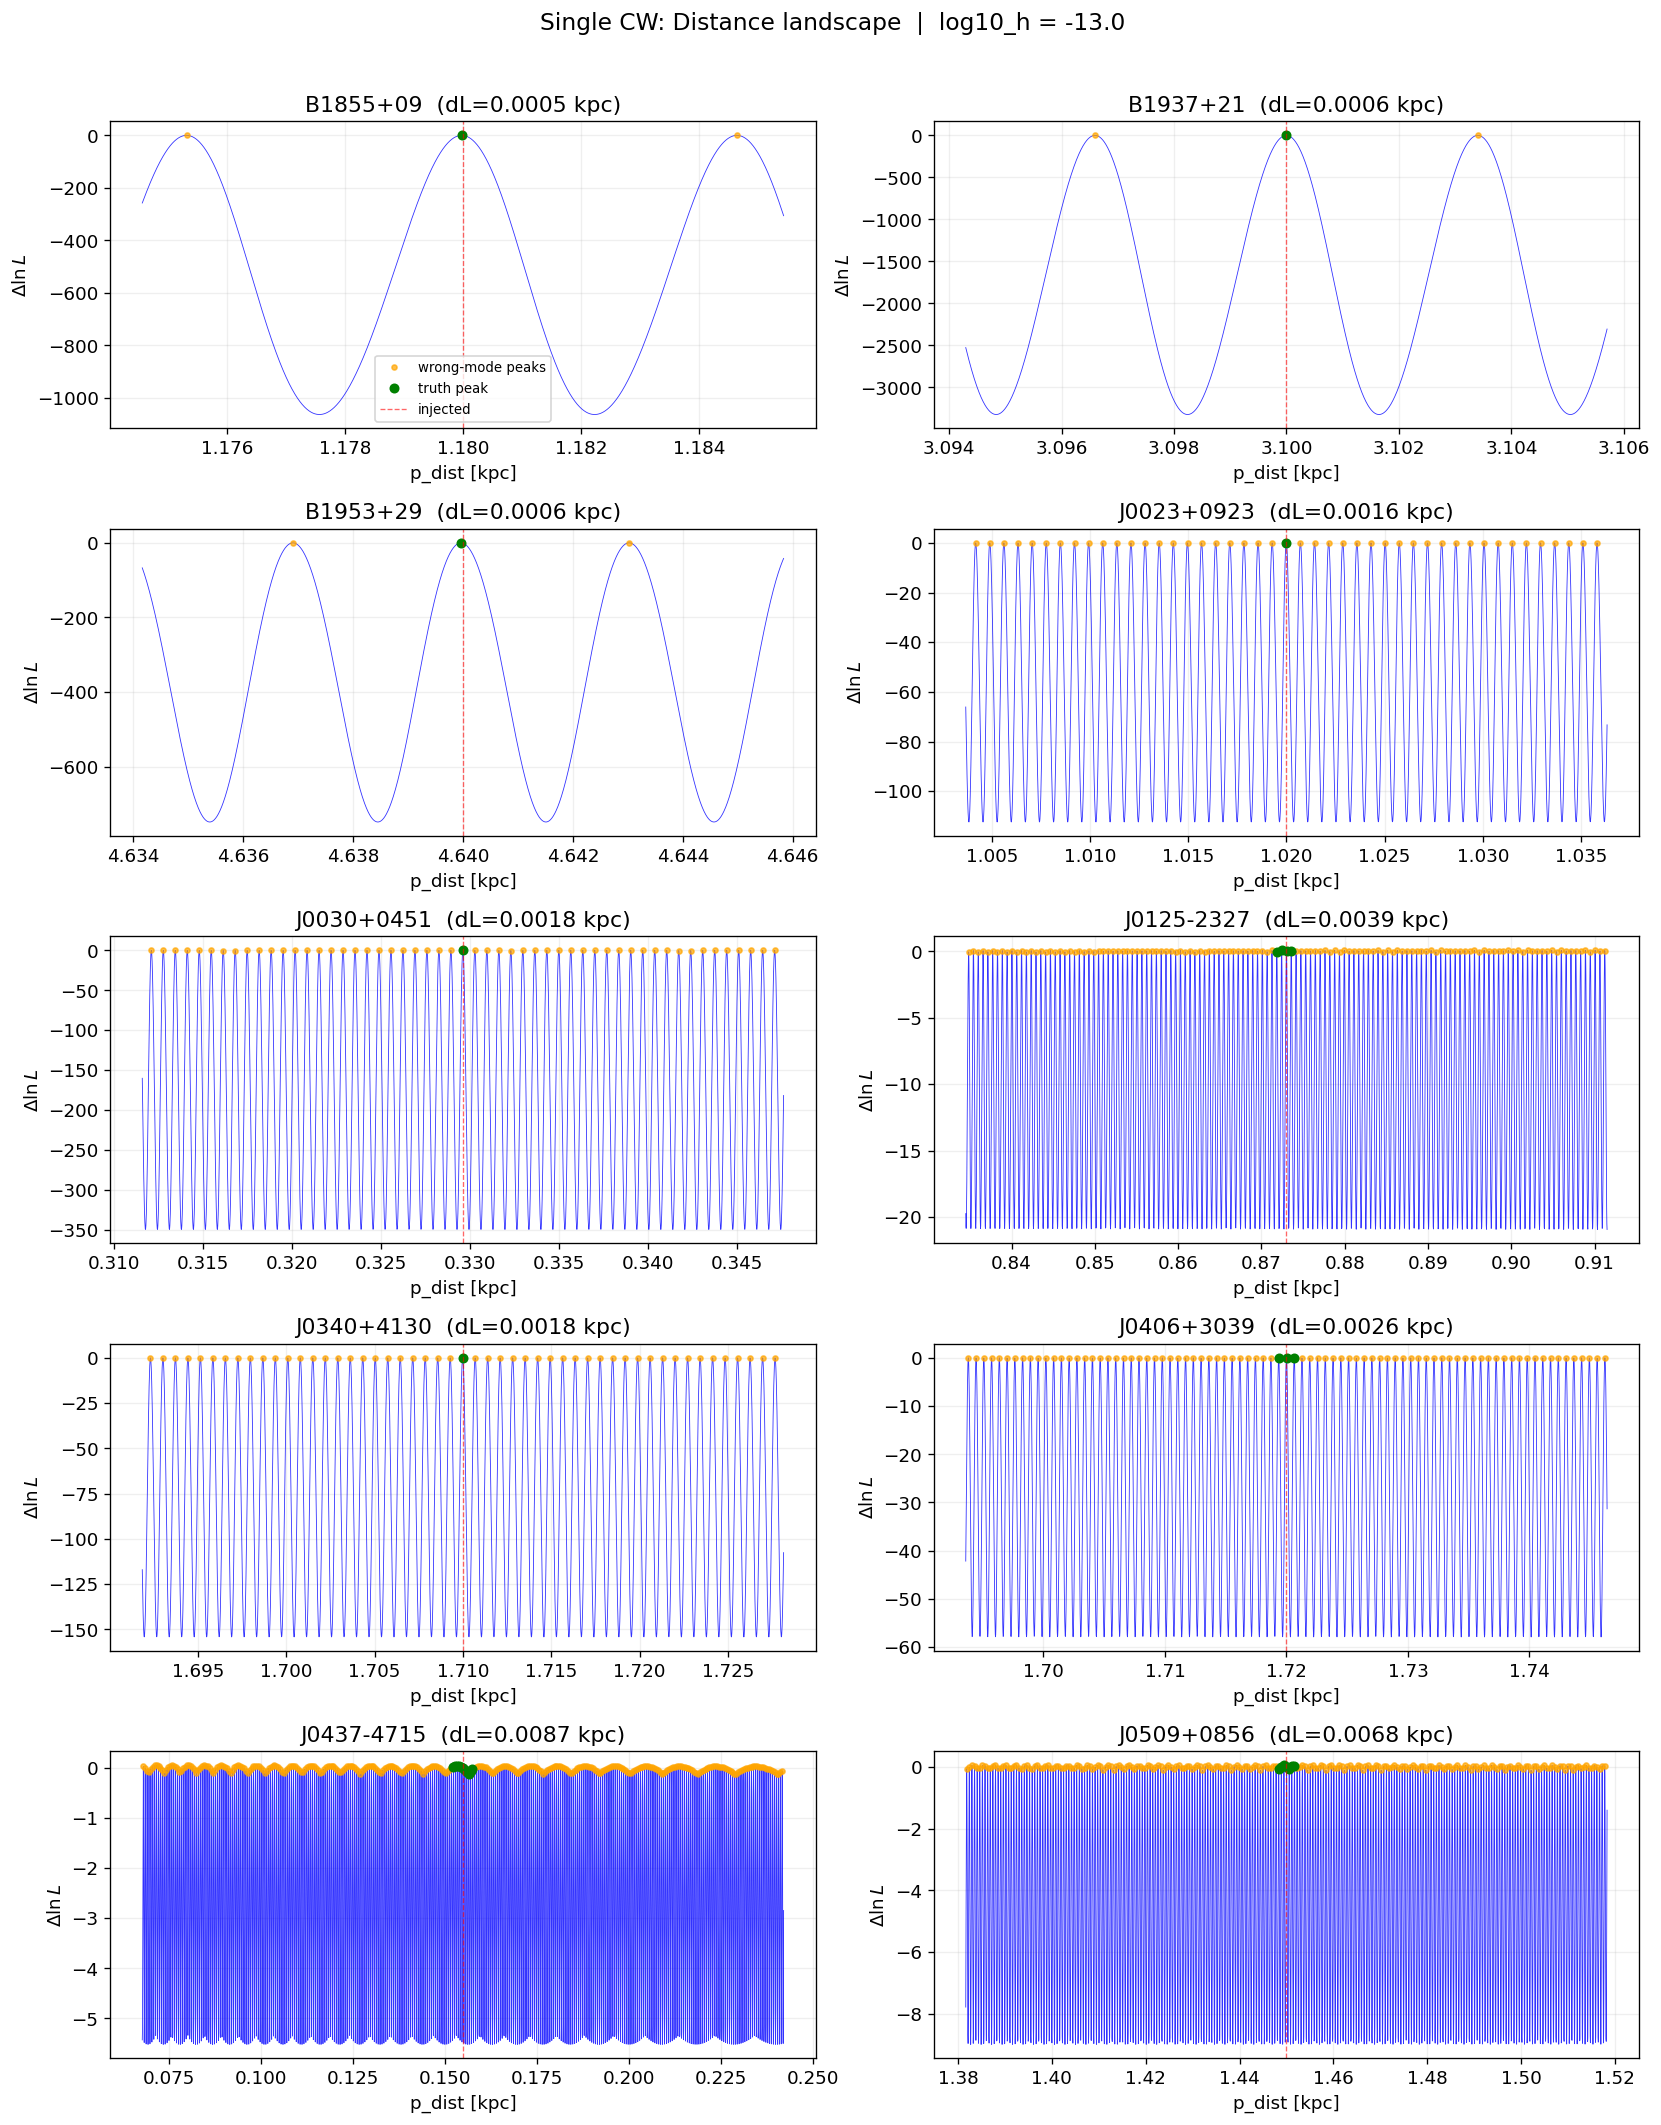

In [5]:
for log10_h in log10_h_values:
    results = all_results[log10_h]
    psr_names = list(results.keys())
    n = len(psr_names)
    ncols = 2
    nrows = (n + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
    axes = axes.flatten()

    for i, pname in enumerate(psr_names):
        ax = axes[i]
        r = results[pname]
        scan_d, scan_ll = r["scan_d"], r["scan_ll"]

        # Normalize to truth peak
        baseline = r["truth_logl"]
        ax.plot(scan_d, scan_ll - baseline, "b-", lw=0.5, alpha=0.8)

        # Mark peaks
        if len(r["peak_distances"]) > 0:
            truth_mask = np.abs(r["peak_distances"] - r["true_dist"]) < 0.3 * r["dL"]
            wrong_mask = ~truth_mask

            if np.any(wrong_mask):
                ax.plot(
                    r["peak_distances"][wrong_mask],
                    r["peak_heights"][wrong_mask] - baseline,
                    "o", color="orange", ms=3, alpha=0.7, label="wrong-mode peaks",
                )
            if np.any(truth_mask):
                ax.plot(
                    r["peak_distances"][truth_mask],
                    r["peak_heights"][truth_mask] - baseline,
                    "o", color="green", ms=5, label="truth peak",
                )

        ax.axvline(r["true_dist"], color="red", ls="--", lw=0.8, alpha=0.6, label="injected")
        ax.set_xlabel("p_dist [kpc]")
        ax.set_ylabel(r"$\Delta \ln L$")
        ax.set_title(f"{pname}  (dL={r['dL']:.4f} kpc)")
        if i == 0:
            ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Single CW: Distance landscape  |  log10_h = {log10_h}", fontsize=14, y=1.01)
    fig.tight_layout()
    plt.show()


## 5. Peak height comparison: truth vs wrong-mode peaks

For each pulsar, we show the distribution of wrong-mode peak heights relative
to the truth peak. If Δln L ≈ 0 for most wrong-mode peaks, the distance
doesn't matter much for a single CW.


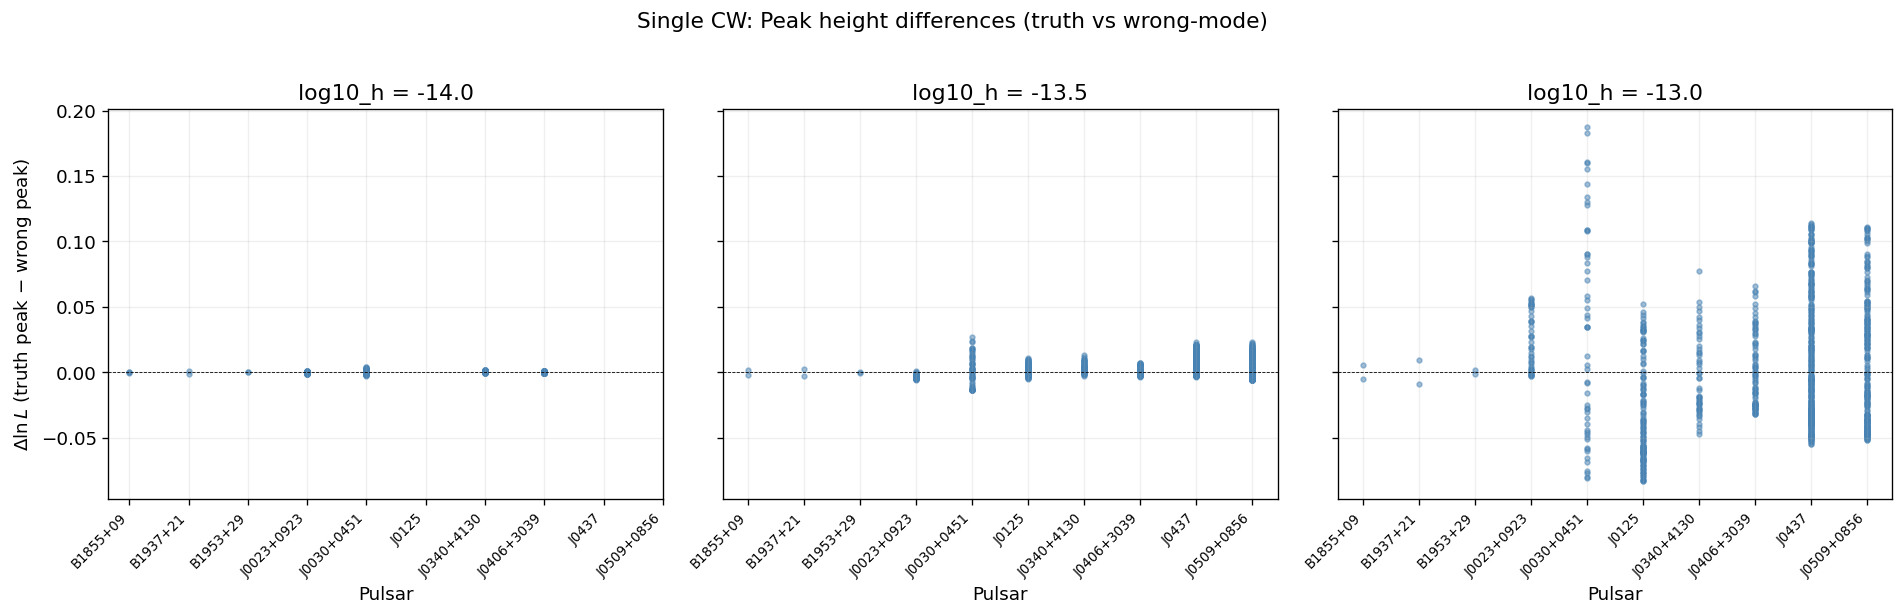

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax_idx, log10_h in enumerate(log10_h_values):
    ax = axes[ax_idx]
    results = all_results[log10_h]

    psr_names_sorted = sorted(results.keys())
    for j, pname in enumerate(psr_names_sorted):
        r = results[pname]
        if r["n_peaks"] < 2:
            continue

        # Δln L for each wrong-mode peak relative to truth
        truth_mask = np.abs(r["peak_distances"] - r["true_dist"]) < 0.3 * r["dL"]
        wrong_heights = r["peak_heights"][~truth_mask]
        if len(wrong_heights) == 0:
            continue

        delta = r["truth_logl"] - wrong_heights
        ax.scatter(
            np.full(len(delta), j), delta,
            s=8, alpha=0.5, color="steelblue",
        )

    ax.set_xticks(range(len(psr_names_sorted)))
    ax.set_xticklabels([n.split("-")[0] if "-" in n else n for n in psr_names_sorted],
                       rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Pulsar")
    ax.set_title(f"log10_h = {log10_h}")
    ax.axhline(0, color="k", ls="--", lw=0.5)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel(r"$\Delta \ln L$ (truth peak $-$ wrong peak)")
fig.suptitle("Single CW: Peak height differences (truth vs wrong-mode)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## 6. Summary statistics

Table of Δln L between truth peak and best wrong-mode peak, per pulsar and signal strength.


In [7]:
print(f"{'Pulsar':16s} | " + " | ".join(f"log10_h={h:5.1f}" for h in log10_h_values))
print("-" * (16 + 3 + len(log10_h_values) * 18))

psr_names = sorted(all_results[log10_h_values[0]].keys())
for pname in psr_names:
    row = f"{pname:16s} | "
    for log10_h in log10_h_values:
        r = all_results[log10_h].get(pname, {})
        delta = r.get("delta_lnL_truth_vs_best_wrong", np.nan)
        n_peaks = r.get("n_peaks", 0)
        row += f"  {delta:7.2f} ({n_peaks:3d}p) | "
    print(row)

print()
print("(Np) = number of peaks found in scan range")
print("Delta ln L > 0 means truth peak is higher than best wrong-mode peak")


Pulsar           | log10_h=-14.0 | log10_h=-13.5 | log10_h=-13.0
-------------------------------------------------------------------------
B1855+09         |     -0.00 (  3p) |     -0.00 (  3p) |     -0.01 (  3p) | 
B1937+21         |     -0.00 (  3p) |     -0.00 (  3p) |     -0.01 (  3p) | 
B1953+29         |     -0.00 (  3p) |     -0.00 (  3p) |     -0.00 (  3p) | 
J0023+0923       |     -0.00 ( 45p) |     -0.01 ( 45p) |     -0.00 ( 45p) | 
J0030+0451       |     -0.00 ( 53p) |     -0.01 ( 53p) |     -0.08 ( 53p) | 
J0125-2327       |       nan (  0p) |     -0.00 (133p) |     -0.08 (133p) | 
J0340+4130       |     -0.00 ( 51p) |     -0.00 ( 51p) |     -0.05 ( 51p) | 
J0406+3039       |     -0.00 ( 81p) |     -0.00 ( 83p) |     -0.03 ( 83p) | 
J0437-4715       |       nan (  0p) |     -0.00 (336p) |     -0.05 (336p) | 
J0509+0856       |       nan (  0p) |     -0.01 (244p) |     -0.05 (244p) | 

(Np) = number of peaks found in scan range
Delta ln L > 0 means truth peak is higher than 

## 7. Joint distance effect: best wrong mode within EM prior

For each pulsar, find the best non-truth peak **within the EM distance prior**
(3-sigma range). Then evaluate the joint likelihood with ALL pulsars simultaneously
at their respective best wrong modes. This answers: "given realistic EM distance
constraints, how much worse is the best alternative distance assignment?"


In [8]:
print(f"{'Signal':12s} | {'ln L (truth)':>14s} | {'ln L (wrong)':>14s} | {'Delta ln L':>12s} | {'Per-pulsar details'}")
print("-" * 90)

for log10_h in log10_h_values:
    # Re-build the likelihood for this signal strength
    rng = np.random.default_rng(seed)
    np.random.seed(seed)
    inj_params = generate_injection_params(
        pta, ent_psrs, num_cw, cw_block_names, log10_h, scenario="single", rng=rng,
    )
    sim_resids = simulate(pta, inj_params)
    resid_map = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}
    logl_fn, param_keys, base_vals = build_disco_likelihood(
        disco_psrs, resid_map, num_cw, inj_params, cw_block_names,
    )

    joint = compute_joint_best_wrong_in_prior(
        logl_fn, base_vals, param_keys,
        ent_psrs, disco_psrs, inj_params,
        cw_block_names=cw_block_names, n_sigma=3.0,
    )

    print(f"h={log10_h:5.1f}     | {joint['ll_truth']:14.2f} | {joint['ll_best_wrong']:14.2f} | {joint['delta_lnL']:12.2f} |")
    for pname, r in joint["per_pulsar"].items():
        sig = [pe.pdist[1] for pe in ent_psrs if pe.name == pname][0]
        print(f"  {pname:16s}: Delta={r['delta_lnL']:8.2f}, peaks_in_prior={r['n_peaks_in_prior']:4d}, "
              f"EM prior width={sig:.4f} kpc")
    jax.clear_caches()


Signal       |   ln L (truth) |   ln L (wrong) |   Delta ln L | Per-pulsar details
------------------------------------------------------------------------------------------
h=-14.0     |       37585.25 |       37586.52 |        -1.27 |
  B1855+09        : Delta=   -0.06, peaks_in_prior= 155, EM prior width=0.1200 kpc
  B1937+21        : Delta=   -0.70, peaks_in_prior= 352, EM prior width=0.2000 kpc
  B1953+29        : Delta=   -5.39, peaks_in_prior= 969, EM prior width=0.9300 kpc
  J0023+0923      : Delta=   -0.02, peaks_in_prior= 918, EM prior width=0.1100 kpc
  J0030+0451      : Delta=   -0.00, peaks_in_prior=  31, EM prior width=0.0036 kpc
  J0125-2327      : Delta=     nan, peaks_in_prior=   0, EM prior width=0.1746 kpc
  J0340+4130      : Delta=   -0.06, peaks_in_prior=1112, EM prior width=0.3400 kpc
  J0406+3039      : Delta=   -0.02, peaks_in_prior= 148, EM prior width=0.3400 kpc
  J0437-4715      : Delta=     nan, peaks_in_prior=   0, EM prior width=0.0010 kpc
  J0509+0856    

## Interpretation

- If Δln L between truth and best wrong-mode peak is **small** (≲ a few) for individual
  pulsars, then knowing the correct distance provides only a marginal likelihood improvement
  for a single CW.
- If the joint Δln L (all pulsars at their best wrong mode within EM prior) is small,
  the contention that "correct distances cause a dramatic likelihood jump" is not supported
  for the single-source case.

Compare these results with the multi-CW analysis in `02_multi_cw_distance_landscape.ipynb`.
